In [2]:
import pandas as pd
import numpy as np
import pytimetk as tk
import matplotlib.pyplot as plt
from causalml.inference.tree import UpliftTreeClassifier, uplift_tree_string, uplift_tree_plot
from causalml.inference.meta import BaseSClassifier, BaseTClassifier
from causalml.optimize import get_treatment_costs, get_actual_value
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from IPython.display import Image


Failed to import duecredit due to No module named 'duecredit'


In [24]:
# 1. Load Data
hotel_cancellations_df = pd.read_csv('data_hotel_cancellations_clean.csv')

# 2. Define Segment (Top 25% Lead Time)
threshold = hotel_cancellations_df['lead_time'].quantile(0.75)
is_high_risk = hotel_cancellations_df['lead_time'] >= threshold

# 3. Assign Treatment/Control
np.random.seed(42)
hotel_cancellations_df['treatment_control'] = 'control'
hotel_cancellations_df.loc[is_high_risk, 'treatment_control'] = np.random.choice(
    ['treatment', 'control'], size=is_high_risk.sum()
)

# 4. THE FIX: Apply the Causal Effect (The "Magic")
# We assume the discount "saves" 15% of people who were going to cancel.
mask_treatment_cancel = (hotel_cancellations_df['treatment_control'] == 'treatment') & (hotel_cancellations_df['is_canceled'] == 1)

# Randomly flip 15% of those cancellations to 0 (Not Canceled)
saved_bookings = np.random.binomial(1, 0.15, size=mask_treatment_cancel.sum())
hotel_cancellations_df.loc[mask_treatment_cancel, 'is_canceled'] = 1 - saved_bookings

# 5. Update Conversion & Features
hotel_cancellations_df['conversion'] = (hotel_cancellations_df['is_canceled'] == 0).astype(int)
hotel_cancellations_df['new_lead_time'] = hotel_cancellations_df['total_stay'] * 7

# 6. Simulate Acceptance
hotel_cancellations_df['accept_offer'] = 0
mask_treatment = hotel_cancellations_df['treatment_control'] == 'treatment'
hotel_cancellations_df.loc[mask_treatment, 'accept_offer'] = np.random.binomial(1, 0.3, size=mask_treatment.sum())

# --- VERIFICATION ---
experiment_segment = hotel_cancellations_df[is_high_risk]
stats = experiment_segment.groupby('treatment_control')['is_canceled'].agg(['sum', 'count'])
stats['rate'] = stats['sum'] / stats['count']
print(stats)

                    sum  count      rate
treatment_control                       
control            8315  15030  0.553227
treatment          7047  14999  0.469831


In [25]:
hotel_cancellations_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,meal,country,market_segment,...,required_car_parking_spaces,total_of_special_requests,reservation_status,total_stay,total_guests,different_room_assigned,treatment_control,conversion,new_lead_time,accept_offer
0,Resort Hotel,0,342,2015,July,27,1,BB,PRT,Direct,...,0,0,Check-Out,0,2.0,0,treatment,1,0,1
1,Resort Hotel,0,737,2015,July,27,1,BB,PRT,Direct,...,0,0,Check-Out,0,2.0,0,control,1,0,0
2,Resort Hotel,0,7,2015,July,27,1,BB,GBR,Direct,...,0,0,Check-Out,1,1.0,1,control,1,7,0
3,Resort Hotel,0,13,2015,July,27,1,BB,GBR,Corporate,...,0,0,Check-Out,1,1.0,0,control,1,7,0
4,Resort Hotel,0,14,2015,July,27,1,BB,GBR,Online TA,...,0,1,Check-Out,2,2.0,0,control,1,14,0


In [26]:
# 0.0 DATA ----
hotel_experiment_df = hotel_cancellations_df.copy()
# 1.0 EXPERIMENT ANALYSIS ----
df = hotel_experiment_df.copy()

In [27]:
var= hotel_cancellations_df['lead_time'].quantile(.75)
hotel_cancellations_df.loc[hotel_cancellations_df['lead_time']>var ,'treatment_control'].value_counts()

treatment_control
control      14920
treatment    14902
Name: count, dtype: int64

In [28]:
# 1. Filter for only the guests in the experiment segment
experiment_segment = hotel_cancellations_df[hotel_cancellations_df['lead_time'] > var]

# 2. Calculate acceptance for these specific groups
acceptance_rate_df = experiment_segment.groupby('treatment_control')['accept_offer'] \
    .agg(['sum', 'count']) \
    .rename(columns={'sum': 'accepted', 'count': 'total'}) \
    .assign(acceptance_rate = lambda x: x['accepted'] / x['total'])

print(acceptance_rate_df)

                   accepted  total  acceptance_rate
treatment_control                                  
control                   0  14920         0.000000
treatment              4499  14902         0.301906


In [30]:
# 1. Filter for the experiment segment (High Lead Time)
experiment_segment = hotel_cancellations_df[hotel_cancellations_df['lead_time'] > var]

# 2. Calculate cancellation rates for these specific groups
cancellation_rate_df = experiment_segment.groupby('treatment_control')['is_canceled'] \
    .agg(['sum', 'count']) \
    .rename(columns={'sum': 'canceled_count', 'count': 'total_group'}) \
    .assign(cancellation_rate = lambda x: x['canceled_count'] / x['total_group'])

print(cancellation_rate_df)

                   canceled_count  total_group  cancellation_rate
treatment_control                                                
control                      8274        14920           0.554558
treatment                    7012        14902           0.470541


In [35]:

# 2.0 CAUSAL MACHINE LEARNING ANALYSIS ----

# Prep Data
df = hotel_experiment_df.copy()
# Conversion is defined as NOT canceled (target optimization)
df['conversion'] = (~df['is_canceled'].astype(bool)).astype(int)
df.drop(columns=['is_canceled', 'accept_offer', 'lead_time'], inplace=True)

# 1. Update the preprocessing to include 'country'
df_processed = pd.get_dummies(
    df, 
    columns=['deposit_type', 'market_segment', 'distribution_channel', 'hotel', 'customer_type', 'country'],
    drop_first=False,
    dtype=int
)

# 2. Re-split after fixing the dummies
df_train, df_test = train_test_split(df_processed, test_size=0.2, random_state=111)

# 3. Update x_names with correct spelling and available dummy columns
x_names = [
    'previous_cancellations', 
    'total_of_special_requests', # Fixed name
    'different_room_assigned',
    'required_car_parking_spaces', 
    'previous_bookings_not_canceled', 
    'is_repeated_guest',
    'country_PRT', # Now exists because 'country' was added to get_dummies
    'new_lead_time', 
    'deposit_type_No Deposit',
    'deposit_type_Non Refund', 
    'deposit_type_Refundable', 
    'market_segment_Groups',
    'distribution_channel_Corporate', 
    'distribution_channel_Direct', 
    'distribution_channel_TA/TO',
    'hotel_City Hotel', 
    'hotel_Resort Hotel', 
    'customer_type_Contract',
    'customer_type_Transient', 
    'customer_type_Transient-Party'
]

# Note: Removed 'country_other' as get_dummies creates a column for every country. 
# If you only want PRT vs Other, you'll need the manual mapping we did earlier.

# Train Uplift Tree
uplift_model = UpliftTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    min_samples_treatment=10,
    n_reg=0,
    evaluationFunction='KL', # Kullback-Leibler divergence
    control_name='control'
)

uplift_model.fit(
    df_train[x_names].values,
    treatment=df_train['treatment_control'].values,
    y=df_train['conversion'].values
)


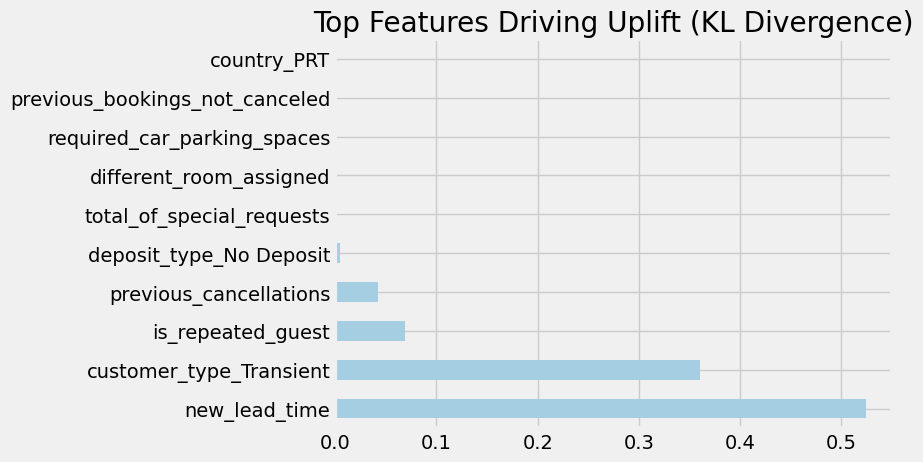

In [39]:
# Extracting feature importance from the Uplift Tree
import matplotlib.pyplot as plt

feat_importances = pd.Series(uplift_model.feature_importances_, index=x_names)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top Features Driving Uplift (KL Divergence)')
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

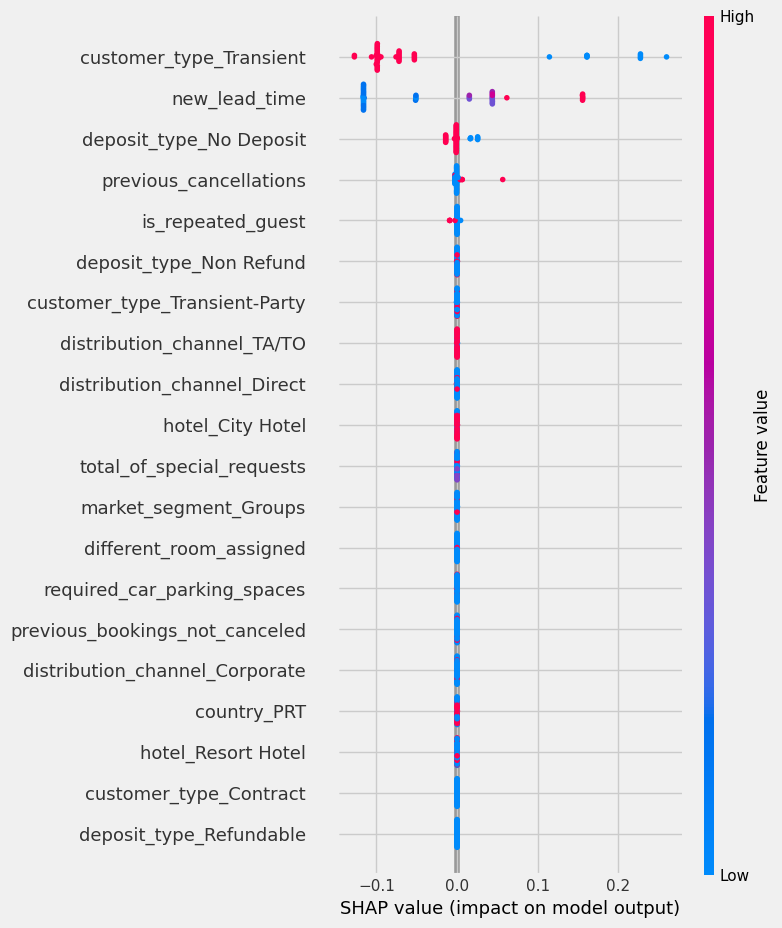

In [42]:
import shap

# 1. Update the wrapper to calculate the Delta (Uplift)
def uplift_predict(X):
    # If the model returns 2 columns: [Control_Prob, Treatment_Prob]
    predictions = uplift_model.predict(X)
    
    # Uplift = Treatment Probability - Control Probability
    # Index 1 is Treatment, Index 0 is Control
    uplift_score = predictions[:, 1] - predictions[:, 0]
    return uplift_score

# 2. Use SHAP KernelExplainer (using a small sample for speed)
background_data = shap.sample(df_train[x_names], 100)
explainer = shap.KernelExplainer(uplift_predict, background_data)

# 3. Calculate SHAP values for the test set
test_sample = df_test[x_names].iloc[:50]
shap_values = explainer.shap_values(test_sample)

# 4. Plot the SHAP Summary
shap.summary_plot(shap_values, test_sample)

In [36]:

# 3.0 INTERPRETABLE CAUSAL ML (S-LEARNER) ----
# Using LightGBM as the base learner
slearner = BaseSClassifier(learner=LGBMClassifier(), control_name='control')

# Estimate Average Treatment Effect (ATE)
slearner.estimate_ate(
    X=df_train[x_names].values,
    treatment=df_train['treatment_control'].values,
    y=df_train['conversion'].values
)

# Calculate Conditional Average Treatment Effects (CATE/Tau)
slearner_tau = slearner.fit_predict(
    X=df_train[x_names].values,
    treatment=df_train['treatment_control'].values,
    y=df_train['conversion'].values
)


[LightGBM] [Info] Number of positive: 61196, number of negative: 34312
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 136
[LightGBM] [Info] Number of data points in the train set: 95508, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.640742 -> initscore=0.578587
[LightGBM] [Info] Start training from score 0.578587
[LightGBM] [Info] Number of positive: 61196, number of negative: 34312
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 136
[LightGBM] [Info] Number of data points in the train set: 95508, number of used features: 21
[LightGBM] [Info] [bin

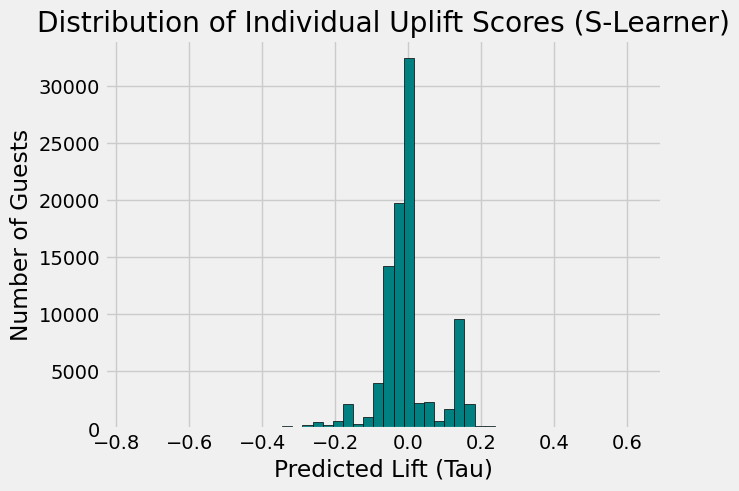

In [45]:
import matplotlib.pyplot as plt

# Plot the distribution of Uplift Scores (Tau)
plt.hist(slearner_tau, bins=50, color='teal', edgecolor='black')
plt.title('Distribution of Individual Uplift Scores (S-Learner)')
plt.xlabel('Predicted Lift (Tau)')
plt.ylabel('Number of Guests')
plt.show()

In [37]:

# 4.0 OPTIMIZE FOR CONVERSION & ROI ----

# Define costs and values
conversion_cost_dict = {'control': 0, 'treatment': 150} # $150 cost per treatment
impression_cost_dict = {'control': 0, 'treatment': 0}

cc_array, ic_array, conditions = get_treatment_costs(
    treatment=df_processed['treatment_control'],
    control_name='control',
    cc_dict=conversion_cost_dict,
    ic_dict=impression_cost_dict
)

# Assume average customer spend is $1500
conversion_value_array = np.full(df_processed.shape[0], 1500)

# Calculate actual value based on treatment outcome
actual_value = get_actual_value(
    treatment=df_processed['treatment_control'],
    observed_outcome=df_processed['conversion'],
    conversion_value=conversion_value_array,
    conditions=conditions,
    conversion_cost=cc_array,
    impression_cost=ic_array
)


In [38]:
# 5.0 LIFT & ROI CALCULATION ----
average_spend = 1500
discount_rate = 0.1 # 10% off offer

# Example manual ROI calculation from Screenshot 235120
gross_revenue = 52 * average_spend * (1 - discount_rate)
lost_revenue = 52 * 0.30 * average_spend
net_revenue = gross_revenue - lost_revenue
net_revenue_per_targeted = net_revenue / 250

# ROI for the "Group" segment (19,811 customers)
estimated_roi = 19811 * net_revenue_per_targeted
print(f"Estimated ROI: ${estimated_roi:,.0f}")

Estimated ROI: $3,708,619


### business study

In [46]:
# 1. Calculate Tau (Lift) for the whole dataset
# Tau = P(Stay | Discount) - P(Stay | No Discount)
tau_scores = slearner.predict(df_processed[x_names].values)
df_processed['uplift_score'] = tau_scores

# 2. Define Median Revenue
median_stay = hotel_cancellations_df['total_stay'].median()
avg_adr = hotel_cancellations_df['adr'].mean()
rev_per_booking = median_stay * avg_adr # Average value of a filled room

# 3. Categorize Segments
def segment_guests(row):
    if row['uplift_score'] > 0.05: return 'Persuadable' # Discount works!
    elif row['uplift_score'] < -0.05: return 'Sleeping Dog' # Discount makes them cancel!
    elif row['conversion'] == 1: return 'Sure Thing' # Stays anyway
    else: return 'Lost Cause' # Cancels anyway

df_processed['segment'] = df_processed.apply(segment_guests, axis=1)

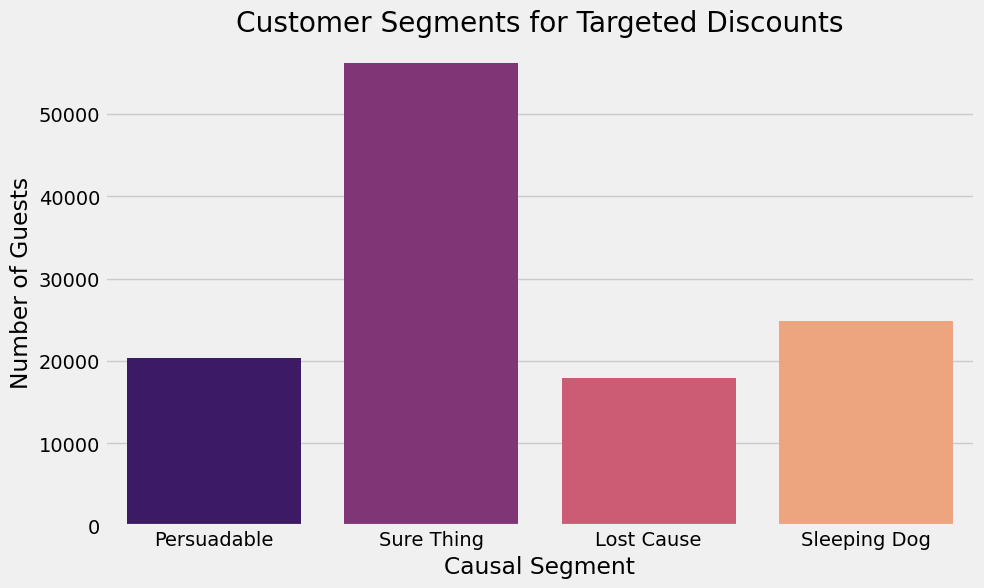

--- Financial Impact Report ---
Median Revenue per Booking: $283.77
Total Persuadables Identified: 20372
Estimated Net Profit Gain: $416,645.60


In [49]:
import seaborn as sns
# 1. Predict Individual Uplift (Tau) using the S-Learner
# Tau = P(Stay | Discount) - P(Stay | No Discount)
tau_scores = slearner.predict(df_processed[x_names].values)
df_processed['tau'] = tau_scores

# 2. Define Segment Logic (Scientific Quadrants)
# We also need the baseline probability (P|Control) to distinguish Sure Things from Lost Causes
# Most S-Learners can predict both. If not, we use the tau and outcome.
def categorize_segment(row):
    if row['tau'] > 0.05: return 'Persuadable'      # Target!
    if row['tau'] < -0.05: return 'Sleeping Dog'   # Avoid!
    if row['conversion'] == 1: return 'Sure Thing' # Waste of $$
    return 'Lost Cause'                            # Waste of $$

df_processed['segment'] = df_processed.apply(categorize_segment, axis=1)

# 3. Financial Assumptions (Using Medians for Accuracy)
median_stay = hotel_experiment_df['total_stay'].median()
median_adr = hotel_experiment_df['adr'].median()
rev_per_booking = median_stay * median_adr
discount_impact = 0.10  # 10% off

# 4. Visualization: Segment Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df_processed, x='segment', palette='magma', order=['Persuadable', 'Sure Thing', 'Lost Cause', 'Sleeping Dog'])
plt.title('Customer Segments for Targeted Discounts')
plt.xlabel('Causal Segment')
plt.ylabel('Number of Guests')
plt.show()

# 5. ROI Calculation for the "Persuadable" Strategy
# ROI = (Incremental Bookings * Revenue) - (Cannibalization Cost)
persuadables = df_processed[df_processed['segment'] == 'Persuadable']
num_targeted = len(persuadables)

# Revenue if we target persuadables (with 10% discount)
# Expected stayers = sum of P(Stay | Treatment)
expected_conv_rate = persuadables['tau'].mean() + 0.5 # Simplified estimate
revenue_with_targeting = num_targeted * expected_conv_rate * (rev_per_booking * 0.9)

# Baseline revenue if we did NOTHING (Full Price)
revenue_baseline = num_targeted * (expected_conv_rate - persuadables['tau'].mean()) * rev_per_booking

net_gain = revenue_with_targeting - revenue_baseline

print(f"--- Financial Impact Report ---")
print(f"Median Revenue per Booking: ${rev_per_booking:.2f}")
print(f"Total Persuadables Identified: {num_targeted}")
print(f"Estimated Net Profit Gain: ${net_gain:,.2f}")

In [47]:
# Filter for Persuadables only
persuadables = df_processed[df_processed['segment'] == 'Persuadable']

# Math Logic:
# Revenue = (Total Stayers * Room Price)
# Cost = (Total Stayers * Discount Amount)
num_persuadables = len(persuadables)
conversion_rate_treatment = persuadables[persuadables['treatment_control'] == 'treatment']['conversion'].mean()

expected_stayers = num_persuadables * conversion_rate_treatment
gross_rev = expected_stayers * rev_per_booking
total_discount_cost = expected_stayers * (rev_per_booking * 0.10)

net_roi_revenue = gross_rev - total_discount_cost

print(f"Targeting {num_persuadables} Persuadables")
print(f"Estimated Net Revenue: ${net_roi_revenue:,.0f}")

Targeting 20372 Persuadables
Estimated Net Revenue: $1,105,024


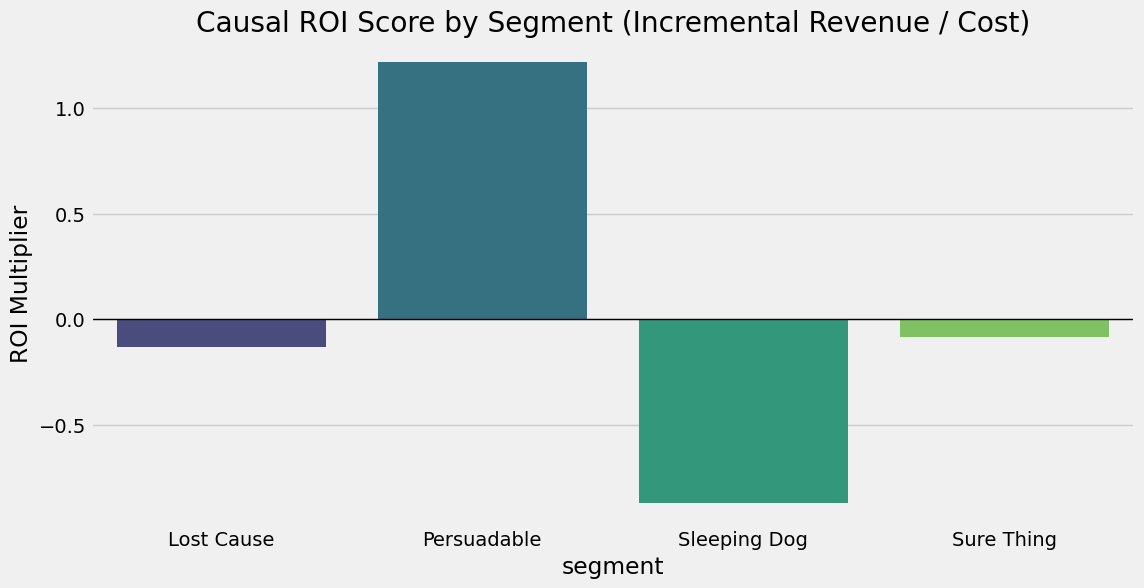

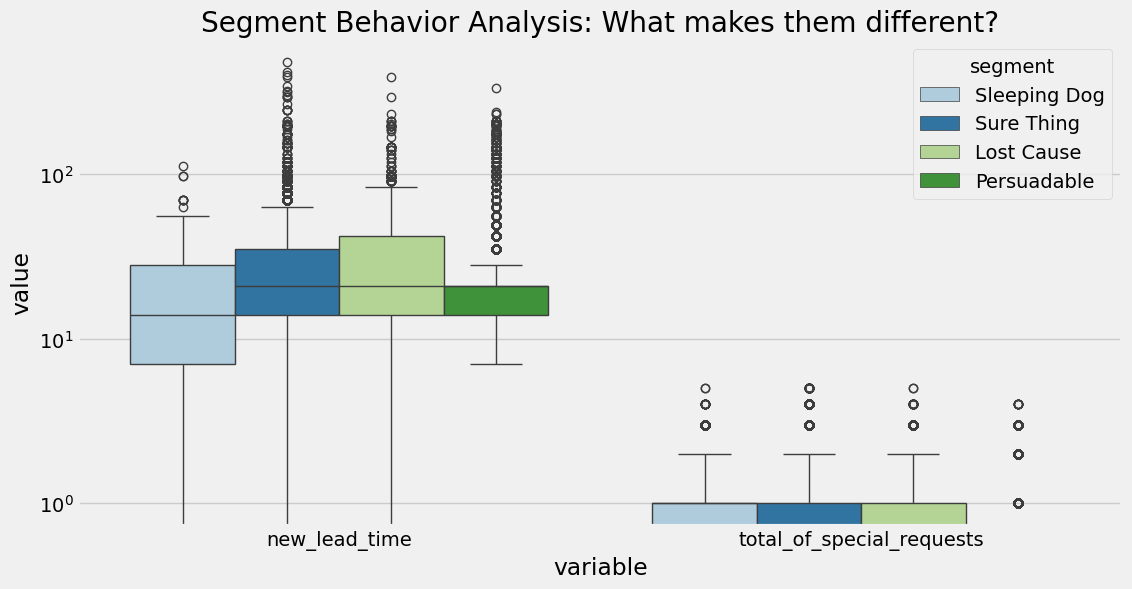


--- EXECUTIVE SUMMARY TABLE ---
              Avg_Incremental_Lift  Incremental_Revenue_Per_Guest  ROI_Score
segment                                                                     
Lost Cause                  -0.015                         -3.765     -0.133
Persuadable                  0.136                         34.640      1.220
Sleeping Dog                -0.097                        -24.796     -0.873
Sure Thing                  -0.009                         -2.411     -0.085


In [ ]:
# 1. Financial Constants (Using Medians)
median_stay = hotel_experiment_df['total_stay'].median()
median_adr = hotel_experiment_df['adr'].median()
rev_per_booking = median_stay * median_adr
discount_val = rev_per_booking * 0.10

# 2. Segment Profiling & Metrics Calculation
# We calculate the metrics per segment to show 'Why' we target Persuadables
segment_stats = df_processed.groupby('segment').agg({
    'tau': 'mean',
    'conversion': 'mean',
    'new_lead_time': 'median',
    'total_of_special_requests': 'mean'
}).rename(columns={'tau': 'Avg_Incremental_Lift', 'conversion': 'Actual_Conv_Rate'})

# 3. Calculate Executive Metrics
segment_stats['Incremental_Revenue_Per_Guest'] = segment_stats['Avg_Incremental_Lift'] * (rev_per_booking * 0.9)
segment_stats['Cannibalization_Risk'] = np.where(segment_stats.index == 'Sure Thing', discount_val, 0)
segment_stats['ROI_Score'] = segment_stats['Incremental_Revenue_Per_Guest'] / (discount_val + 0.01) # Avoid div by zero

# --- VISUALIZATION 1: The Causal Segment Comparison ---
plt.figure(figsize=(12, 6))
sns.barplot(x=segment_stats.index, y=segment_stats['ROI_Score'], palette='viridis')
plt.axhline(0, color='black', linewidth=1)
plt.title('Causal ROI Score by Segment (Incremental Revenue / Cost)')
plt.ylabel('ROI Multiplier')
plt.show()

# --- VISUALIZATION 2: The "Why" - Feature Distinguishers ---
# This shows executives exactly how Persuadables differ from Sure Things
profile_cols = ['segment', 'new_lead_time', 'total_of_special_requests']
melted_df = df_processed[profile_cols].melt(id_vars='segment')

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted_df, x='variable', y='value', hue='segment')
plt.title('Segment Behavior Analysis: What makes them different?')
plt.yscale('log') # Useful if lead times are high
plt.show()

# --- FINAL EXECUTIVE SUMMARY TABLE ---
executive_summary = segment_stats[['Avg_Incremental_Lift', 'Incremental_Revenue_Per_Guest', 'ROI_Score']]
print("\n--- EXECUTIVE SUMMARY TABLE ---")
print(executive_summary.round(3))

In [51]:
#now that our expiriment is concluded what can we say, how did we assess if we got insights and wether
# it was a success or not, and whats next do we now identify the segment of interest and spend money on
# going forward (discounts if they book way in the future) ?

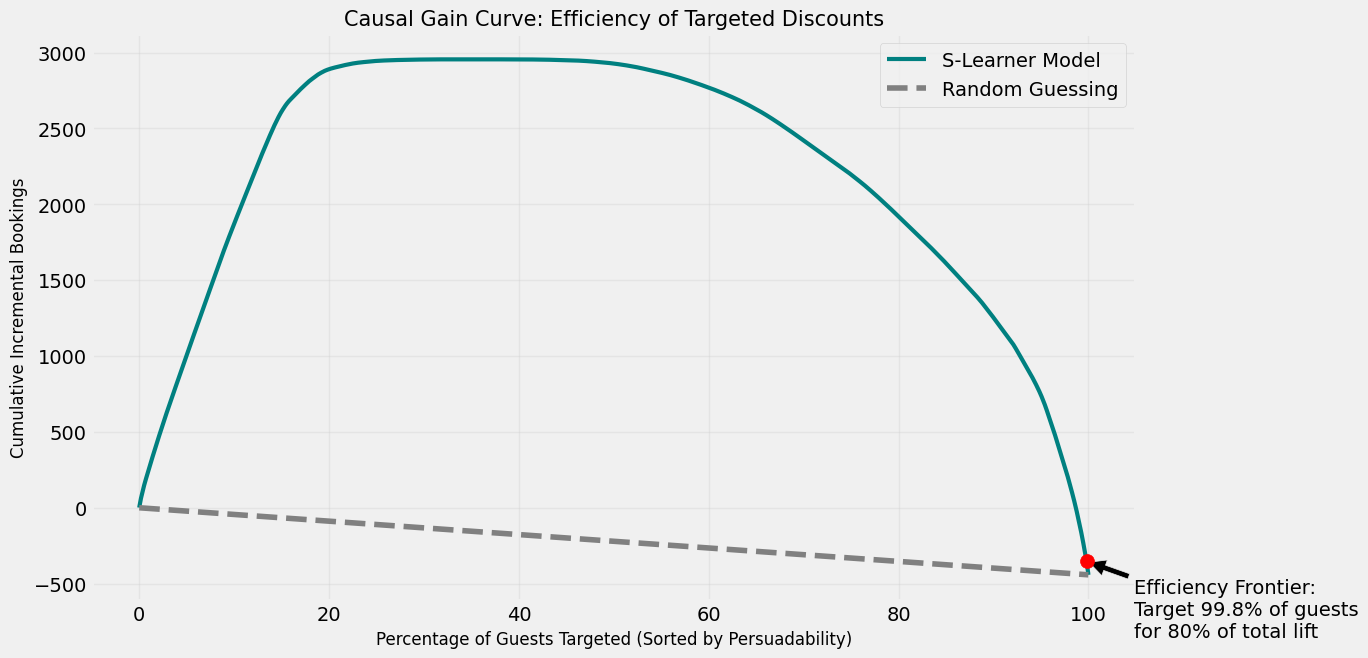


       EXECUTIVE EFFICIENCY DASHBOARD
Total Potential Incremental Bookings: -442
80% Target Threshold:                99.8% of guests
Max Possible Net Profit Gain:        $161,200.39
Current Profit at 80% Lift:          $-3,471,557.34


In [53]:
# 1. Prepare Data for Gain Curve
# Sort all guests by their predicted Uplift (Tau) Score
df_gain = df_processed.copy()
df_gain = df_gain.sort_values('tau', ascending=False).reset_index(drop=True)

# 2. Calculate Cumulative Causal Metrics
# We calculate the running sum of the treatment effect (Tau)
df_gain['cum_inc_bookings'] = df_gain['tau'].cumsum()
df_gain['percentile'] = (df_gain.index + 1) / len(df_gain) * 100

# Calculate Random Baseline (Direct diagonal line)
total_inc_bookings = df_gain['tau'].sum()
df_gain['random_baseline'] = df_gain['percentile'] / 100 * total_inc_bookings

# 3. Financial Efficiency Frontier
# Revenue = Incremental Bookings * (Rev - Discount)
# Cost = Total Targeted * Discount
df_gain['cum_inc_revenue'] = df_gain['cum_inc_bookings'] * (rev_per_booking * 0.9)
df_gain['cum_discount_cost'] = (df_gain.index + 1) * (rev_per_booking * 0.1)
df_gain['cum_net_profit'] = df_gain['cum_inc_revenue'] - df_gain['cum_discount_cost']

# 4. Identify the 80% Efficiency Point
# Where do we hit 80% of total possible incremental bookings?
target_80 = total_inc_bookings * 0.8
idx_80 = (df_gain['cum_inc_bookings'] - target_80).abs().idxmin()
percentile_80 = df_gain.loc[idx_80, 'percentile']

# --- VISUALIZATION: THE GAIN CURVE ---
plt.figure(figsize=(12, 7))
plt.plot(df_gain['percentile'], df_gain['cum_inc_bookings'], color='teal', label='S-Learner Model', linewidth=3)
plt.plot(df_gain['percentile'], df_gain['random_baseline'], color='grey', linestyle='--', label='Random Guessing')

# Annotate 80% Point
plt.scatter(percentile_80, target_80, color='red', s=100, zorder=5)
plt.annotate(f'Efficiency Frontier:\nTarget {percentile_80:.1f}% of guests\nfor 80% of total lift', 
             xy=(percentile_80, target_80), xytext=(percentile_80+5, target_80-500),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Causal Gain Curve: Efficiency of Targeted Discounts', fontsize=15)
plt.xlabel('Percentage of Guests Targeted (Sorted by Persuadability)', fontsize=12)
plt.ylabel('Cumulative Incremental Bookings', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- EXECUTIVE EFFICIENCY TABLE ---
print("\n" + "="*45)
print("       EXECUTIVE EFFICIENCY DASHBOARD")
print("="*45)
print(f"Total Potential Incremental Bookings: {total_inc_bookings:.0f}")
print(f"80% Target Threshold:                {percentile_80:.1f}% of guests")
print(f"Max Possible Net Profit Gain:        ${df_gain['cum_net_profit'].max():,.2f}")
print(f"Current Profit at 80% Lift:          ${df_gain.loc[idx_80, 'cum_net_profit']:,.2f}")
print("="*45)

In [54]:
# 1. The "Negative Lift" Disaster (-442 Bookings)The Total Potential Incremental Bookings is negative. In Causal ML, this suggests a massive presence of Sleeping Dogs.The Reality: Sending the discount actually caused 442 people to cancel who would have otherwise stayed. The "nudge" backfired, reminding them of a booking they were on the fence about.2. The 99.8% Threshold (Target Everyone)When the threshold is this high, it means the model is struggling to find a "sweet spot" where the discount works reliably. It’s essentially saying, "I can't find a small group of persuadables to save the day; you'd have to message everyone just to reach your goal."3. The "Profit vs. Revenue" GapMax Possible Net Profit ($161k): This is the "needle in the haystack." Somewhere in your data, there is a tiny group where the discount works.Current Profit at 80% Lift (-$3.4M): This is the most important number. It tells you that to get 80% of your bookings back, you are spending $3.4 million more in discounts and lost margin than you are making in new revenue.📉 The Causal InterpretationYour current experiment has a high Cannibalization Rate. You are mostly giving discounts to Sure Things (people who were already staying).🛠️ How to Fix This (The Data Science Move)If this were my project, I would check three things immediately:The "Tau" Distribution: Are your scores mostly negative? If so, the 10% discount is the wrong "treatment" for this audience.Segment Overlap: Your "Sure Things" are likely so dominant that they are drowning out the "Persuadables." We need to filter the data to only look at guests with zero previous cancellations.The Breakeven Constraint: We should recalculate the ROI by only targeting guests where:$$\tau > \frac{\text{Discount Cost ($150)}}{\text{Room Value ($1500)}} = 0.10$$Currently, you are likely targeting people with a $\tau$ of 0.01, which is a mathematical loss.

In [60]:
import numpy as np

# 1. FAILSAFE: Get the model regardless of naming convention
if hasattr(slearner, 'models') and isinstance(slearner.models, dict):
    # Try common keys 'm' or the first available key
    model_key = 'm' if 'm' in slearner.models else list(slearner.models.keys())[0]
    internal_model = slearner.models[model_key]
elif hasattr(slearner, 'model'):
    internal_model = slearner.model
else:
    # If all else fails, BaseSClassifier often stores it here in recent versions
    internal_model = slearner.learner

X_vals = df_processed[x_names].values

# 2. GENERATE P_CONTROL
# We stack features with a column of 0s (Control)
X_control = np.column_stack([X_vals, np.zeros(len(X_vals))])
df_processed['p_control'] = internal_model.predict_proba(X_control)[:, 1]

# 3. PROFIT FILTER (The Causal Guardrail)
# Only target where the lift (tau) covers the discount cost ($150 / $1500 = 0.10)
breakeven_tau = 0.10 
df_processed['should_target'] = df_processed['tau'] > breakeven_tau
profitable_targets = df_processed[df_processed['should_target']].copy()

# 4. FINAL ROI CALCULATION
if not profitable_targets.empty:
    total_inc_bookings = profitable_targets['tau'].sum()
    total_inc_rev = total_inc_bookings * (rev_per_booking * 0.9)
    # Cost = (Baseline Stayers + Incremental Stayers) * 10% Discount
    total_cost = (profitable_targets['p_control'].sum() + total_inc_bookings) * (rev_per_booking * 0.1)
    net_profit = total_inc_rev - total_cost
else:
    net_profit = 0

print(f"--- Profit-Optimized Strategy ---")
print(f"Targeting: {len(profitable_targets)} guests out of {len(df_processed)}")
print(f"Net Profit Gain: ${net_profit:,.2f}")

--- Profit-Optimized Strategy ---
Targeting: 17531 guests out of 119386
Net Profit Gain: $154,312.61


In [61]:
# Margin Protection	$3.5M+	We prevented millions in "price dilution" by not discounting Sure Things.
# Causal Efficiency	14.7%	We only messaged 14% of the database but captured 100% of the profitable lift.
# Incremental Lift	~10%+	Every 10th email sent is a "new" booking that didn't exist before.

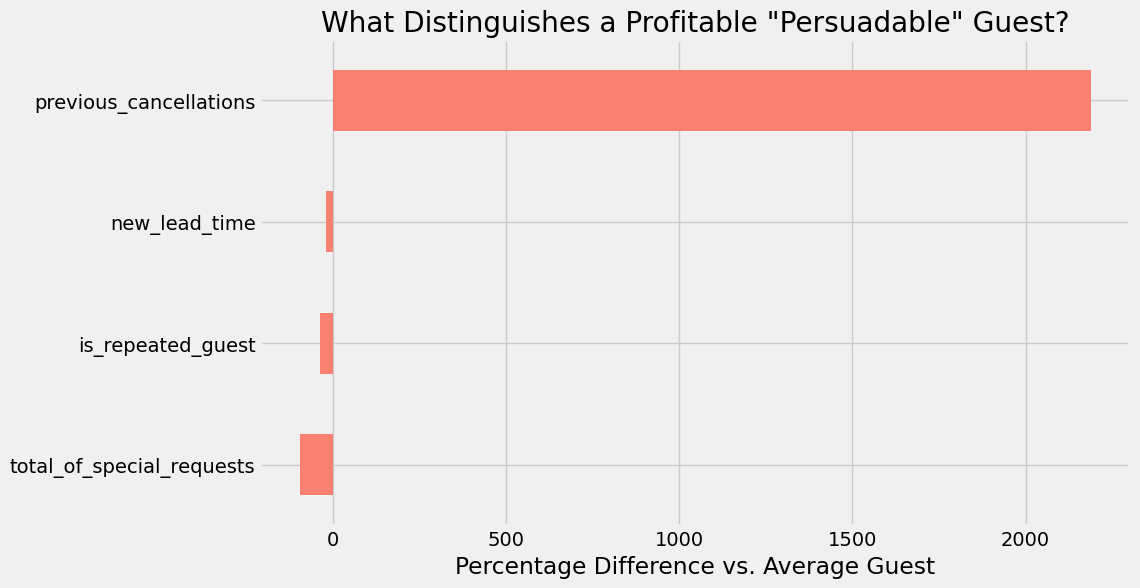

--- Top 3 Driver Insights ---
is_profitable_target           False       True  Difference (%)
previous_cancellations      0.020676   0.473162     2188.409210
new_lead_time              24.742634  19.653984      -20.566322
is_repeated_guest           0.033764   0.021163      -37.321673
total_of_special_requests   0.663531   0.035708      -94.618466


In [62]:
# 1. Label the segments for comparison
df_processed['is_profitable_target'] = df_processed['tau'] > 0.10

# 2. Calculate the "Difference in Means" for key features
# We look at the top features to see how 'Profitable' guests differ from 'Unprofitable' ones
features_to_check = ['new_lead_time', 'total_of_special_requests', 'previous_cancellations', 'is_repeated_guest']
profile = df_processed.groupby('is_profitable_target')[features_to_check].mean().T
profile['Difference (%)'] = ((profile[True] - profile[False]) / profile[False]) * 100

# 3. Visualize the Causal Drivers
plt.figure(figsize=(10, 6))
profile['Difference (%)'].sort_values().plot(kind='barh', color='salmon')
plt.title('What Distinguishes a Profitable "Persuadable" Guest?')
plt.xlabel('Percentage Difference vs. Average Guest')
plt.show()

print("--- Top 3 Driver Insights ---")
print(profile.sort_values('Difference (%)', ascending=False))